# Episodic CAL Mini Pilot — d_cost = 6

M2 Pro Mac / MPS用。N=2,4,8を各10 episode、固定scenario bankで学習します。Start-state dual、TensorBoard、tqdm、checkpoint再開、正式stochastic Cost Critic Calibrationを一括実行します。

In [1]:
from pathlib import Path
from copy import deepcopy
import json, math, platform
import numpy as np
import torch
import yaml
from IPython.display import display, HTML

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir():
    ROOT = ROOT.parent
RUN_DIR = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
TRAIN_EPISODES_PER_N = 10
CALIBRATION_SCENARIOS_PER_N = 3
CALIBRATION_REPEATS = 3
AGENT_COUNTS = [2, 4, 8]
D_COST = 6.0
DUAL_LR = 0.001
TRAINING_SEED = 0
RESUME_IF_AVAILABLE = True
print({'root': str(ROOT), 'run_dir': str(RUN_DIR), 'd_cost': D_COST, 'dual_lr': DUAL_LR})

{'root': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes', 'run_dir': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps', 'd_cost': 6.0, 'dual_lr': 0.001}


In [2]:
print({
    'platform': platform.platform(),
    'python': platform.python_version(),
    'torch': torch.__version__,
    'mps_built': torch.backends.mps.is_built(),
    'mps_available': torch.backends.mps.is_available(),
})
if not torch.backends.mps.is_available():
    raise RuntimeError('MPSが利用できません。.venvカーネルを選択し、VS Code/Jupyterを再起動してください。')
probe = torch.ones((512, 512), device='mps')
print({'mps_device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())})
del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_built': True, 'mps_available': True}
{'mps_device': 'mps:0', 'probe': 134217728.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import generate_random_traffic_bank, load_scenario_bank, save_scenario_bank

settings = yaml.safe_load((ROOT / 'notebooks' / 'windows' / 'experiment_settings.yaml').read_text(encoding='utf-8'))
s = settings['scenario']
RUN_DIR.mkdir(parents=True, exist_ok=True)
train_bank_path = RUN_DIR / 'training_bank.json'
calibration_bank_path = RUN_DIR / 'calibration_bank.json'

def generation_kwargs():
    return dict(
        base_size=s['longitudinal_length'], transverse_size=s['transverse_size'],
        spatial_scaling_mode='fixed', altitude_range=(s['altitude_min'], s['altitude_max']),
        minimum_initial_distance=s['minimum_initial_separation'],
        d_safe=10.0, d_warn=30.0, d_eng=50.0,
        los_prediction_threshold=s['interaction_threshold'], prediction_horizon=s['prediction_horizon'],
        initial_speed_fraction_range=(s['initial_speed_fraction_min'], s['initial_speed_fraction_max']),
        acceleration_range=(s['acceleration_min'], s['acceleration_max']),
        velocity_limit_range=(s['velocity_limit_min'], s['velocity_limit_max']),
        require_predicted_conflict=True,
    )

def interleaved_bank(per_n, seed_root):
    by_n = {n: generate_random_traffic_bank(n, per_n, seed=seed_root + n, **generation_kwargs()) for n in AGENT_COUNTS}
    return [by_n[n][i] for i in range(per_n) for n in AGENT_COUNTS]

if train_bank_path.exists():
    training_bank = load_scenario_bank(train_bank_path)
else:
    training_bank = interleaved_bank(TRAIN_EPISODES_PER_N, s['seed_training'])
    save_scenario_bank(train_bank_path, training_bank)
if calibration_bank_path.exists():
    calibration_bank = load_scenario_bank(calibration_bank_path)
else:
    calibration_bank = interleaved_bank(CALIBRATION_SCENARIOS_PER_N, s['seed_evaluation'])
    save_scenario_bank(calibration_bank_path, calibration_bank)
print({'training_scenarios': len(training_bank), 'calibration_scenarios': len(calibration_bank), 'training_order': [x['actual_agent_count'] for x in training_bank[:12]]})

{'training_scenarios': 30, 'calibration_scenarios': 9, 'training_order': [2, 4, 8, 2, 4, 8, 2, 4, 8, 2, 4, 8]}


In [4]:
base = deepcopy(settings['base_config'])
maximum_reference_time = max(max(item['reference_arrival_times']) for item in training_bank + calibration_bank)
max_steps = int(math.ceil(s['timeout_multiplier'] * maximum_reference_time / base['environment']['dt_base']))
base['environment'].update({'agent_count': 2, 'max_agent_count': 8, 'max_steps': max_steps})
base['scenario']['training_agent_count_distribution'] = {2: 1/3, 4: 1/3, 8: 1/3}
base['learning'].update({
    'd_cost': D_COST, 'cal_lambda_lr': DUAL_LR,
    'constraint_semantics': 'episodic_start_state',
    'cal_variant': 'episodic_dual_replay_gradient',
})
base['training'].update({
    'total_environment_steps_budget': None, 'learning_starts': 2000,
    'dual_learning_starts': 2000, 'dual_update_period': 1,
    'dual_batch_size': 256, 'updates_per_environment_step': 1,
    'checkpoint_every_episodes': 1,
})
base.setdefault('monitoring', {}).update({
    'enabled': True, 'progress_bar': True, 'tensorboard': True,
    'auto_launch_tensorboard': True, 'open_browser': True,
})
base['performance'].update({'profile': 'exact', 'safety_backend': 'serial'})
base['device'] = 'mps'
base['seed'] = TRAINING_SEED
config = load_config(ROOT / 'configs' / 'full.yaml', overrides=base)
resolved_path = RUN_DIR / 'resolved_config.json'
resolved_path.write_text(json.dumps(config.to_dict(), ensure_ascii=False, indent=2), encoding='utf-8')
print({
    'max_steps': max_steps, 'learning_starts': config.training.learning_starts,
    'dual_learning_starts': config.training.dual_learning_starts,
    'd_cost': config.learning.d_cost, 'dual_lr': config.learning.cal_lambda_lr,
    'cal_variant': config.learning.cal_variant, 'device': config.device,
})

{'max_steps': 1686, 'learning_starts': 2000, 'dual_learning_starts': 2000, 'd_cost': 6.0, 'dual_lr': 0.001, 'cal_variant': 'episodic_dual_replay_gradient', 'device': 'mps'}


In [5]:
from uav_safe_marl.runners.trainer import SafeRLTrainer

latest_checkpoint = RUN_DIR / 'checkpoints' / 'latest.pt'
final_checkpoint = RUN_DIR / 'checkpoints' / 'final.pt'
trainer = SafeRLTrainer(config, build_env(config), RUN_DIR / 'training')
if RESUME_IF_AVAILABLE and latest_checkpoint.exists():
    trainer.load_checkpoint(latest_checkpoint, resume_training=True)
    trainer.logger.truncate_after_episode(trainer.completed_episodes)
    print(f'{trainer.completed_episodes} episode地点から再開します。')
print({
    'backend_device': str(trainer.backend.device),
    'completed': trainer.completed_episodes,
    'remaining': len(training_bank) - trainer.completed_episodes,
    'tensorboard_dir': str(RUN_DIR / 'training' / 'tensorboard'),
})
display(HTML(f"<b>TensorBoard:</b> 学習開始後にブラウザが自動で開きます。ログ: <code>{RUN_DIR / 'training' / 'tensorboard'}</code>"))

{'backend_device': 'mps', 'completed': 0, 'remaining': 30, 'tensorboard_dir': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/training/tensorboard'}


In [6]:
remaining = len(training_bank) - trainer.completed_episodes
try:
    new_history = trainer.train(
        episodes=remaining, scenarios=training_bank, live_display=True,
        checkpoint_path=latest_checkpoint,
    ) if remaining > 0 else []
    trainer.save_checkpoint(final_checkpoint)
finally:
    trainer.env.close()
print({
    'completed_episodes': trainer.completed_episodes,
    'environment_steps': trainer.total_environment_steps,
    'gradient_updates': trainer.total_gradient_updates,
    'checkpoint': str(final_checkpoint),
})

Training:   0%|          | 0/30 [00:00<?, ?episode/s]

TensorBoard: http://127.0.0.1:61849/
{'completed_episodes': 30, 'environment_steps': 11872, 'gradient_updates': 9873, 'checkpoint': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/checkpoints/final.pt'}


In [7]:
from uav_safe_marl.evaluation import calibrate_cost_critic, evaluate_mean_policy_cost_diagnostic

eval_base = deepcopy(config.to_dict())
eval_base['monitoring'].update({'enabled': False, 'progress_bar': False, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
eval_config = load_config(ROOT / 'configs' / 'full.yaml', overrides=eval_base)
evaluator = SafeRLTrainer(eval_config, build_env(eval_config), RUN_DIR / 'frozen_evaluation')
evaluator.load_checkpoint(final_checkpoint, resume_training=False)
try:
    calibration = calibrate_cost_critic(
        evaluator, calibration_bank, repeats=CALIBRATION_REPEATS,
        output_dir=RUN_DIR / 'cost_calibration',
    )
    mean_diagnostic = evaluate_mean_policy_cost_diagnostic(
        evaluator, calibration_bank, repeats=1,
        output_dir=RUN_DIR / 'mean_policy_diagnostic',
    )
finally:
    evaluator.env.close()
print(json.dumps({'formal_stochastic_calibration': calibration['overall'], 'mean_policy_diagnostic': {k:v for k,v in mean_diagnostic.items() if k != 'rows'}}, ensure_ascii=False, indent=2))

{
  "formal_stochastic_calibration": {
    "count": 27,
    "mc_return_mean": 22.60962409476045,
    "mc_return_median": 12.724073738279467,
    "mean_estimate_bias": -19.270266701001177,
    "ucb_estimate_bias": -18.488549480058996,
    "mean_estimate_mae": 20.467451440290642,
    "mean_estimate_rmse": 32.456513816032924,
    "ucb_estimate_mae": 20.029188244758302,
    "correlation": 0.5705256665228169,
    "empirical_ucb_coverage": 0.3333333333333333,
    "mc_return_p75": 35.131049035416964,
    "mc_return_p90": 57.83098983300301,
    "mc_return_p95": 77.31425436877498,
    "mc_return_max": 97.2802911603388
  },
  "mean_policy_diagnostic": {
    "definition": "deterministic mean-action deployment diagnostic; not SAC Cost Critic calibration",
    "diagnostic_kind": "mean_policy_deployment_cost",
    "runtime_hocbf": true,
    "execution_mode": "mean",
    "critic_rollout_semantics_match": false,
    "count": 9,
    "discounted_episode_cost_mean": 20.799479040460447,
    "discounted_ep

{
  "episodes": 30,
  "environment_steps": 11872,
  "gradient_updates": 9873,
  "episode_success_rate": 1.0,
  "separation_violation_rate": 0.0,
  "mean_discounted_training_cost": 24.917071892219692,
  "final_lambda": 0.0,
  "max_lambda": 0.0,
  "final_dual_constraint_estimate": 4.760625839233398,
  "calibration_mc_mean": 22.60962409476045,
  "calibration_mc_median": 12.724073738279467,
  "calibration_mc_p75": 35.131049035416964,
  "calibration_ucb_mean": 4.121074614701448,
  "calibration_ucb_coverage": 0.3333333333333333,
  "fraction_mc_above_d_cost": 0.6296296296296297,
  "fraction_ucb_above_d_cost": 0.2962962962962963,
  "d_cost": 6.0,
  "dual_lr": 0.001
}


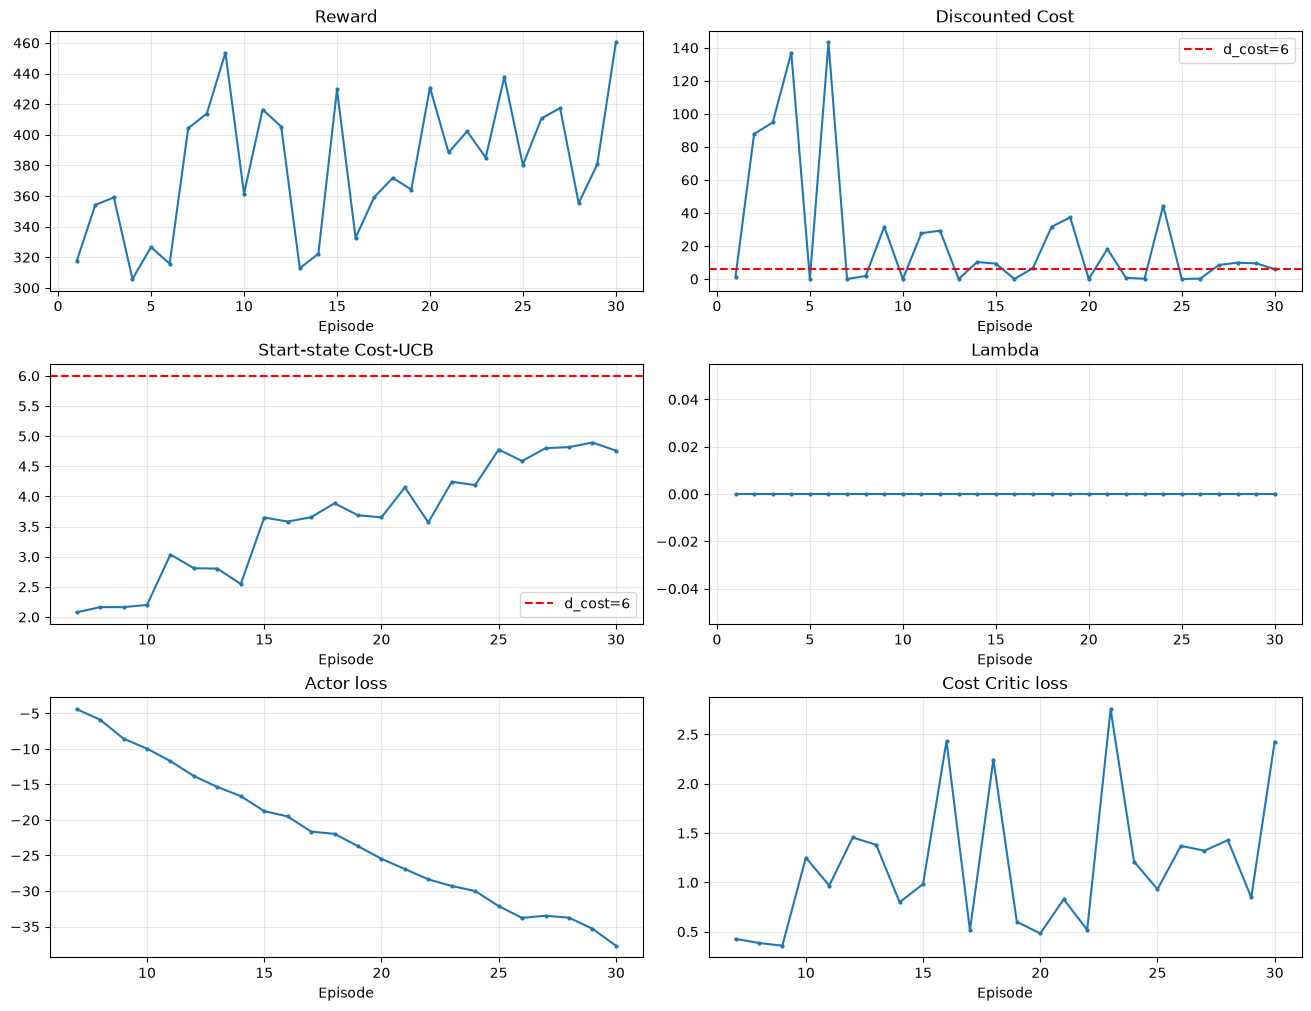

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/mini_pilot_learning_curves.png


In [8]:
import matplotlib.pyplot as plt

metrics_path = RUN_DIR / 'training' / 'metrics.jsonl'
rows = [json.loads(line) for line in metrics_path.read_text(encoding='utf-8').splitlines() if line.strip()]
mc = np.asarray([r['discounted_episode_cost'] for r in calibration['rows']], dtype=float)
ucb = np.asarray([r['start_state_cost_ucb'] for r in calibration['rows']], dtype=float)
active_ticks = sum(r['active_agent_ticks'] for r in rows)
summary = {
    'episodes': len(rows),
    'environment_steps': rows[-1]['cumulative_environment_steps'],
    'gradient_updates': rows[-1]['gradient_updates'],
    'episode_success_rate': float(np.mean([r['episode_success'] for r in rows])),
    'separation_violation_rate': sum(r['separation_violation_pair_ticks'] for r in rows) / max(1, sum(r['active_pair_ticks'] for r in rows)),
    'mean_discounted_training_cost': float(np.mean([r['discounted_episode_cost'] for r in rows])),
    'final_lambda': rows[-1]['lambda'],
    'max_lambda': float(max(r['lambda'] for r in rows)),
    'final_dual_constraint_estimate': rows[-1].get('dual_constraint_estimate'),
    'calibration_mc_mean': float(mc.mean()),
    'calibration_mc_median': float(np.median(mc)),
    'calibration_mc_p75': float(np.quantile(mc, 0.75)),
    'calibration_ucb_mean': float(ucb.mean()),
    'calibration_ucb_coverage': calibration['overall']['empirical_ucb_coverage'],
    'fraction_mc_above_d_cost': float(np.mean(mc > D_COST)),
    'fraction_ucb_above_d_cost': float(np.mean(ucb > D_COST)),
    'd_cost': D_COST, 'dual_lr': DUAL_LR,
}
(RUN_DIR / 'mini_pilot_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(summary, ensure_ascii=False, indent=2))

episodes = np.arange(1, len(rows) + 1)
fig, axes = plt.subplots(3, 2, figsize=(13, 10), constrained_layout=True)
series = [('episode_reward','Reward'), ('discounted_episode_cost','Discounted Cost'), ('dual_constraint_estimate','Start-state Cost-UCB'), ('lambda','Lambda'), ('actor_loss','Actor loss'), ('cost_critic_loss','Cost Critic loss')]
for ax, (key, title) in zip(axes.flat, series):
    ax.plot(episodes, [r.get(key, np.nan) for r in rows], marker='o', markersize=2)
    if key in {'discounted_episode_cost', 'dual_constraint_estimate'}:
        ax.axhline(D_COST, color='red', linestyle='--', label='d_cost=6')
        ax.legend()
    ax.set_title(title); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)
figure_path = RUN_DIR / 'mini_pilot_learning_curves.png'
fig.savefig(figure_path, dpi=160)
plt.show()
print('Saved:', figure_path)